In [2]:
import pandas as pd
df=pd.read_csv('Experience-Salary.csv')
df.head()

,exp(in months),salary(in thousands)
0,18.290293,16.521825
1,17.023407,11.666234
2,26.343613,23.167255
3,19.105834,20.877145
4,27.742516,23.166236


Análise exploratória dos dados

In [6]:
df.isna().sum()

exp(in months)          0
salary(in thousands)    0
dtype: int64

Não temos dados faltantes

In [7]:
df.describe()

,exp(in months),salary(in thousands)
count,1000.000000,1000.000000
mean,26.157825,26.722597
std,8.717091,8.844761
min,0.697594,-1.276342
25%,20.073600,20.531008
50%,25.875225,26.745576
75%,32.406986,32.615753
max,49.463222,55.297016


Se observarmos bem, temos algo bem estranho... salário negativo? teremos que tratar essas linhas, vejamos se são muitas linhas...

In [244]:
print(f"Total de registros negativos: {(df['salary(in thousands)'] < 0).sum()}")

Total de registros negativos: 2


Bom, como são poucas, só serão retiradas.

In [250]:
df=df[df['salary(in thousands)'] >= 0]

In [251]:
df.describe()

,exp(in months),salary(in thousands)
count,998.000000,998.000000
mean,26.198820,26.777503
std,8.676579,8.767962
min,0.697594,2.832976
25%,20.090774,20.580347
50%,25.891328,26.767413
75%,32.413938,32.619291
max,49.463222,55.297016


Observando a média, vemos uma variância interessante, mas vou medir, para ter certeza:
Variância
Covariância
Correlação de Pearson

In [252]:
from scipy.stats import pearsonr
def eda(df):
    print("Variância")
    print(df.var())
    print("")
    print("Covariância")
    print(df.cov())
    r, p = pearsonr(df['exp(in months)'], df['salary(in thousands)'])
    print("")
    print(f'Pearson: {round(r,3)}')
    return r,p

In [278]:
r,p=eda(df)

Variância
exp(in months)          75.283029
salary(in thousands)    76.877156
dtype: float64

Covariância
                      exp(in months)  salary(in thousands)
exp(in months)             75.283029             61.528472
salary(in thousands)       61.528472             76.877156

Pearson: 0.809


Temos uma variância interessante, de fato, nem tão alta para não encontrarmos padrão, mas nem tão baixa para terem o mesmo valor sempre.

Covariância positiva, ou seja, se x sobe y sobe, interessante também. Vamos avaliar com a correlação de Pearson.

Peason de 0.81 indica que temos um padrão linear. Mas vamos plotar um scatter (gráfico de dispersão) e observar isso.

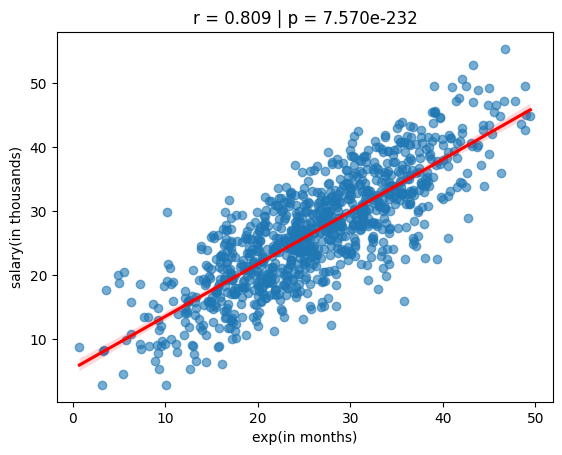

In [255]:
import matplotlib.pyplot as plt
import seaborn as sns
def plot_pearson(df,r,p):
    sns.regplot(x='exp(in months)', y='salary(in thousands)', data=df, 
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.title(f"r = {r:.3f} | p = {p:.3e}")
    plt.show()
plot_pearson(df,r,p)

Realmente temos um comportamento linear, entretanto, aparentemente, temos alguns outliers. Para confirmar isso, vamos medir.

In [256]:
def outlier(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[column] < limite_inferior) | (df[column] > limite_superior)]
    print(f"Número de outliers encontrados em {column}: {len(outliers)}")
outlier('exp(in months)')
outlier('salary(in thousands)')

Número de outliers encontrados em exp(in months): 1
Número de outliers encontrados em salary(in thousands): 2


<Axes: >

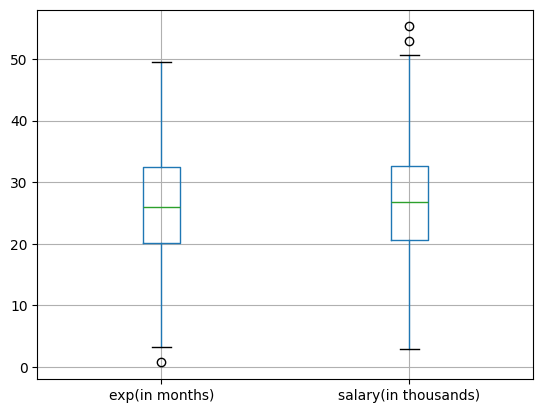

In [257]:
df.boxplot()

Testarei uma limpeza mais agressiva.

In [258]:
def clean_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return df[(df[column] >= limite_inferior) & (df[column] <= limite_superior)]
df_limpo = clean_outliers(df, 'exp(in months)')
df_limpo = clean_outliers(df_limpo, 'salary(in thousands)')
print(f"Total original: {len(df)} | Total após limpeza: {len(df_limpo)}")

Total original: 998 | Total após limpeza: 995


Perdemos pouquíssimos dados, vamos ver como ficou a covariância e Pearson.

Variância
exp(in months)          74.140171
salary(in thousands)    75.275605
dtype: float64

Covariância
                      exp(in months)  salary(in thousands)
exp(in months)             74.140171             60.213446
salary(in thousands)       60.213446             75.275605

Pearson: 0.806


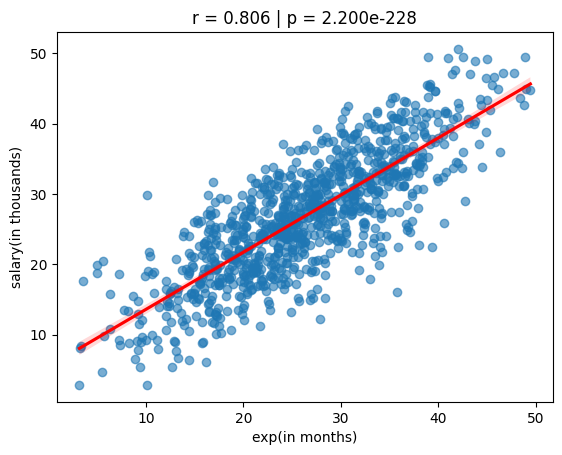

In [277]:
r_l,p_l=eda(df_limpo)
plot_pearson(df_limpo,r_l,p_l)

<Axes: >

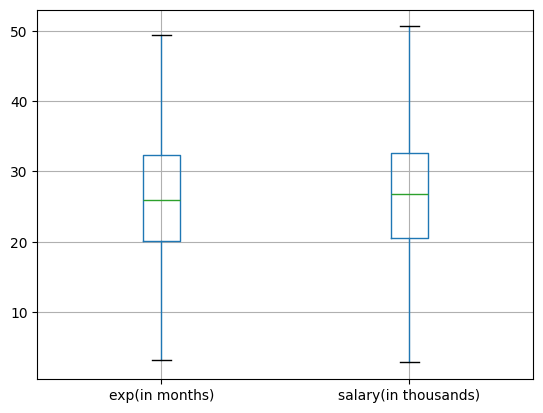

In [261]:
df_limpo.boxplot()

Tivemos uma diferença de correlação, indicando que os outliers agregam valor ao dataset, então eles serão mantidos. Vamos para o modelo.

In [273]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

def run_model(df):
    X = df[['exp(in months)']]
    y = df['salary(in thousands)']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1,random_state=150)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

In [274]:
run_model(df)

R² Score: 0.65
MAE: 4.23
MSE: 28.19
RMSE: 5.31


A título de curiosidade, vejamos como se desempenha sem os outliers.

In [275]:
run_model(df_limpo)

R² Score: 0.57
MAE: 4.41
MSE: 32.23
RMSE: 5.68


De fato temos uma piora nas métricas, o que Pearson e a covariância já tinham nos contado anteriormente.

Podemos observar uma "coincidência" aqui, p²=r², mas isso não é coincidência, o artigo Thirteen Ways to Look at the Correlation Coefficient nos fala sobre isso. Com o que fala o artigo, podemos tirar uma conclusão: a divisão de treino e teste REPRESENTA o dataset como um todo para o modelo.

In [284]:
print(f'Pearson ao quadrado: {round(r*r,2)}\nR²: 0.65')

Pearson ao quadrado: 0.65
R²: 0.65
